# Assignment 2

## *The adverse health effects of air pollution - are we making any progress?*

<p><img src=files/air.jpg width="900"></p>
<p><strong>Credit:</strong>  <a href="https://www.flickr.com/people/44221799@N08/">Flickr/E4C</a> </p>

In [73]:
# Load relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as sm
import warnings
import datetime as dt

warnings.filterwarnings("ignore")  # Suppress all warnings

<h2>Introduction</h2>
<p><strong>Business Context.</strong> Air pollution is a very serious issue that the global population is currently dealing with. The abundance of air pollutants is not only contributing to global warming, but it is also causing problematic health issues to the population. There have been numerous efforts to protect and improve air quality across most nations. However, it seems that we are making very little progress. One of the main causes of this is the fact that the majority of air pollutants are derived from the burning of fossil fuels such as <em>coal</em>. Big industries and several other economical and political factors have slowed the progress towards the use of renewable energy by promoting the use of fossil fuels. Nevertheless, if we educate the general population and create awareness of this issue, we will be able to overcome this problem in the future.      </p>
<p>For this case, you have been hired as a data science consultant for an important environmental organization. In order to promote awareness of environmental and greenhouse gas issues, your client is interested in a study of <strong>plausible impacts of air contamination on the health of the global population</strong>. They have gathered some <em>raw</em> data provided by the <a href="https://www.who.int/">World Health Organization</a>, <a href="http://www.healthdata.org/">The Institute for Health Metrics and Evaluation</a> and the <a href="https://www.worldbank.org/">World Bank Group</a>. Your task is to conduct data analysis, search for potential information, and create visualizations that the client can use for their campaigns and grant applications. </p>
<p><strong>Analytical Context.</strong> You are given a folder, named <code>files</code> with <em>raw</em> data. This data contains quite a large number of variables and it is in a fairly disorganized state. In addition, one of the datasets contains very poor documentation, segmented into several datasets. Your objective will be to:</p>
<ol>
<li>Extract and clean the relevant data. You will have to manipulate several datasets to obtain useful information for the case. </li>
<li>Conduct Exploratory Data Analysis. You will have to create meaningful plots, formulate meaningful hypotheses and study the relationship between various indicators related to air pollution.</li>
</ol>
<p>Additionally, the client has some broad questions they would like to answer:<br />
1. Are we making any progress in reducing the amount of emitted pollutants across the globe?<br />
2. Which are the critical regions where we should start environmental campaigns?<br />
3. Are we making any progress in the prevention of deaths related to air pollution?<br />
4. Which demographic characteristics seem to correlate with the number of health-related issues derived from air pollution? </p>

<h2>Extracting and cleaning relevant data</h2>
<p>Let's take a look at the data provided by the client in the <code>files</code> folder. There, we see another folder  named <code>WDI_csv</code> with several CSV files corresponding to the World Bank's primary <a href="https://datacatalog.worldbank.org/dataset/world-development-indicators">World Development Indicators</a>. The client stated that this data may contain some useful information relevant to our study, but they have not told us anything aside from that. Thus, we are on our own in finding and extracting the relevant data for our study. This we will do next. </p>
<p>Let's take a peek at the file <code>WDIData.csv</code>:</p>

In [74]:
WDI_data = pd.read_csv("./files/WDI_csv/WDIData.csv")
print(WDI_data.columns)
print(WDI_data.info())
WDI_data

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', 'Unnamed: 64'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377256 entries, 0 to 377255
Data columns (total 65 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    377256 non-null  object 
 1   Country Code    377256 non-null  object 
 2   Indicator Name  377256 non-null  object 
 3   Indicator Co

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,Unnamed: 64
0,Arab World,ARB,"2005 PPP conversion factor, GDP (LCU per inter...",PA.NUS.PPP.05,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"2005 PPP conversion factor, private consumptio...",PA.NUS.PRVT.PP.05,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,82.783289,83.120303,83.533457,83.897596,84.171599,84.510171,NaN,NaN,NaN,NaN
3,Arab World,ARB,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,86.428272,87.070576,88.176836,87.342739,89.130121,89.678685,90.273687,NaN,NaN,NaN
4,Arab World,ARB,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,73.942103,75.244104,77.162305,75.538976,78.741152,79.665635,80.749293,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377251,Zimbabwe,ZWE,Women who believe a husband is justified in be...,SG.VAW.NEGL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,21.400000,NaN,NaN,NaN,21.400000,NaN,NaN,NaN,NaN,NaN
377252,Zimbabwe,ZWE,Women who believe a husband is justified in be...,SG.VAW.REFU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,16.900000,NaN,NaN,NaN,14.500000,NaN,NaN,NaN,NaN,NaN
377253,Zimbabwe,ZWE,Women who were first married by age 15 (% of w...,SP.M15.2024.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,3.900000,NaN,NaN,NaN,3.700000,NaN,NaN,NaN,NaN,NaN
377254,Zimbabwe,ZWE,Women who were first married by age 18 (% of w...,SP.M18.2024.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,30.500000,NaN,NaN,33.500000,32.400000,NaN,NaN,NaN,NaN,NaN


<p>The data seems to have a large number of indicators dating from 1960. There are also columns containing country names and codes. Notice that the first couple of rows say <code>Arab World</code>, which may indicate that the data contains broad regional data as well. We notice also that there are at least 100,000 entries with <code>NaN</code> values for each year column.</p>
<p>Since we are interested in environmental indicators, we must get rid of any rows not relevant to our study. However, the number of indicators seems to be quite large and a manual inspection seems impossible. Let's load the file <code>WDISeries.csv</code> which seems to contain more information about the indicators:</p>

In [75]:
WDI_ids = pd.read_csv("./files/WDI_csv/WDISeries.csv")
print(WDI_ids.columns)
WDI_ids.head()

Index(['Series Code', 'Topic', 'Indicator Name', 'Short definition',
       'Long definition', 'Unit of measure', 'Periodicity', 'Base Period',
       'Other notes', 'Aggregation method', 'Limitations and exceptions',
       'Notes from original source', 'General comments', 'Source',
       'Statistical concept and methodology', 'Development relevance',
       'Related source links', 'Other web links', 'Related indicators',
       'License Type', 'Unnamed: 20'],
      dtype='object')


,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,AG.AGR.TRAC.NO,Environment: Agricultural production,"Agricultural machinery, tractors",NaN,Agricultural machinery refers to the number of...,NaN,Annual,NaN,NaN,Sum,...,NaN,NaN,"Food and Agriculture Organization, electronic ...",A tractor provides the power and traction to m...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0,NaN
1,AG.CON.FERT.PT.ZS,Environment: Agricultural production,Fertilizer consumption (% of fertilizer produc...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0,NaN
2,AG.CON.FERT.ZS,Environment: Agricultural production,Fertilizer consumption (kilograms per hectare ...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0,NaN
3,AG.LND.AGRI.K2,Environment: Land use,Agricultural land (sq. km),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,NaN,Sum,...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agricultural land constitutes only a part of a...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0,NaN
4,AG.LND.AGRI.ZS,Environment: Land use,Agricultural land (% of land area),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,NaN,Weighted average,...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agriculture is still a major sector in many ec...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0,NaN


<p>Bingo! The <code>WDI_ids</code> DataFrame contains a column named <code>Topic</code>. Moreover, it seems that <em>Environment</em> is listed as a key topic in the column.</p>

<h3>Exercise 1:</h3>
<p>Extract all the rows that have the topic key <em>Environment</em> in <code>WDI_ids</code>. Add to the resulting DataFrame a new column named <code>Subtopic</code> which contains the corresponding subtopic of the indicator. For example, the subtopic of <code>Environment: Agricultural production</code> is <code>Agricultural production</code>. Which subtopics do you think are of interest to us?</p>
<p><strong>Hint:</strong> Remember that you can apply string methods to Series using the <code>str()</code> method of <code>pandas</code>. </p>

**Answer.**

In [76]:
# subset of rows that have the topic key Environment
environment_df = WDI_ids[WDI_ids["Topic"].str.title().str.startswith("Environment")]

# extract subtopic and create new column
environment_df["Subtopic"] = environment_df["Topic"].str[13:]
environment_df.insert(2, "Subtopic", environment_df.pop("Subtopic"))

environment_df.head()
list(environment_df["Subtopic"].unique())

['Agricultural production',
 'Land use',
 'Energy production & use',
 'Emissions',
 'Biodiversity & protected areas',
 'Density & urbanization',
 'Freshwater',
 'Natural resources contribution to GDP']

ANSWER

-------

<h3>Exercise 2:</h3>
<p>Use the results of Exercise 1 to create a new DataFrame with the history of all emissions indicators for countries and major regions. Call this new DataFrame <code>Emissions_df</code>. How many emissions indicators are in the study?</p>

**Answer.**

In [77]:
# extract rows from environment_df that are related to emissions
Emissions_df = environment_df[environment_df["Subtopic"] == "Emissions"]

# create list of unique emission indicators
emissions = list(Emissions_df["Indicator Name"].unique())
print(f"The number of emission indicators in the study are: {len(emissions)}")
print(f"The following is a list of emission indicators: {emissions}")

The number of emission indicators in the study are: 42
The following is a list of emission indicators: ['CO2 intensity (kg per kg of oil equivalent energy use)', 'CO2 emissions from gaseous fuel consumption (kt)', 'CO2 emissions from gaseous fuel consumption (% of total)', 'CO2 emissions (kg per 2010 US$ of GDP)', 'CO2 emissions (kt)', 'CO2 emissions from liquid fuel consumption (kt)', 'CO2 emissions from liquid fuel consumption (% of total)', 'CO2 emissions (metric tons per capita)', 'CO2 emissions (kg per PPP $ of GDP)', 'CO2 emissions (kg per 2011 PPP $ of GDP)', 'CO2 emissions from solid fuel consumption (kt)', 'CO2 emissions from solid fuel consumption (% of total)', 'Other greenhouse gas emissions, HFC, PFC and SF6 (thousand metric tons of CO2 equivalent)', 'Other greenhouse gas emissions (% change from 1990)', 'Total greenhouse gas emissions (kt of CO2 equivalent)', 'Total greenhouse gas emissions (% change from 1990)', 'HFC gas emissions (thousand metric tons of CO2 equivalent)

In [78]:
# finalize the dataframe by subsetting from WDI_data to get country and major region data for each emission indicator
Emissions_df = WDI_data[WDI_data["Indicator Name"].isin(emissions)]
Emissions_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,Unnamed: 64
64,Arab World,ARB,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,Arab World,ARB,Agricultural methane emissions (thousand metri...,EN.ATM.METH.AG.KT.CE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,Arab World,ARB,Agricultural nitrous oxide emissions (% of total),EN.ATM.NOXE.AG.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,Arab World,ARB,Agricultural nitrous oxide emissions (thousand...,EN.ATM.NOXE.AG.KT.CE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191,Arab World,ARB,CO2 emissions (kg per 2010 US$ of GDP),EN.ATM.CO2E.KD.GD,NaN,NaN,NaN,NaN,NaN,NaN,...,0.757162,0.770413,0.737665,0.769023,NaN,NaN,NaN,NaN,NaN,NaN


-------

<h3>Exercise 3:</h3>
<p>The DataFrame <code>Emissions_df</code> has one column per year of observation. Data in this form is usually referred to as data in <em>wide format</em>, as the number of columns is high. However, it might be easier to query and filter the data if we had a single column containing the year in which each indicator was calculated. This way, <em>each observation will be represented by a single row</em>. Use the <code>pandas</code> function <a href="https://pandas.pydata.org/docs/reference/api/pandas.melt.html"><code>melt()</code></a> to reshape the <code>Emissions_df</code> data into <em>long format</em>. The resulting DataFrame should contain a pair of new columns named <code>Year</code> and <code>Indicator Value</code>:</p>

**Answer.**

In [79]:
# check column names
print(Emissions_df.columns)

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', 'Unnamed: 64'],
      dtype='object')


In [80]:
# melt the df and reshape it to long format
Emissions_df_long = pd.melt(
    Emissions_df,
    id_vars = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name = "Year",
    value_name = "Indicator Value"
)

# display the df
Emissions_df_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
0,Arab World,ARB,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1960,NaN
1,Arab World,ARB,Agricultural methane emissions (thousand metri...,EN.ATM.METH.AG.KT.CE,1960,NaN
2,Arab World,ARB,Agricultural nitrous oxide emissions (% of total),EN.ATM.NOXE.AG.ZS,1960,NaN
3,Arab World,ARB,Agricultural nitrous oxide emissions (thousand...,EN.ATM.NOXE.AG.KT.CE,1960,NaN
4,Arab World,ARB,CO2 emissions (kg per 2010 US$ of GDP),EN.ATM.CO2E.KD.GD,1960,NaN


-------

<h3>Exercise 4:</h3>
<p>The column <code>Indicator Value</code> of the new <code>Emissions_df</code> contains a bunch of <code>NaN</code> values. Additionally, the <code>Year</code> column contains an <code>Unnamed: 64</code> value. What procedure should we follow to clean these missing values in our DataFrame? Proceed with your suggested cleaning process.</p>

**Answer.**

In [81]:
# check how many rows we have in total
Emissions_df_long.shape

(676368, 6)

In [82]:
# check the countries and regions that have NaN values
nan_df = Emissions_df_long[Emissions_df_long["Indicator Value"].isna()]
list(nan_df["Country Name"].unique())

['Arab World',
 'Caribbean small states',
 'Central Europe and the Baltics',
 'Early-demographic dividend',
 'East Asia & Pacific',
 'East Asia & Pacific (excluding high income)',
 'East Asia & Pacific (IDA & IBRD countries)',
 'Euro area',
 'Europe & Central Asia',
 'Europe & Central Asia (excluding high income)',
 'Europe & Central Asia (IDA & IBRD countries)',
 'European Union',
 'Fragile and conflict affected situations',
 'Heavily indebted poor countries (HIPC)',
 'High income',
 'IBRD only',
 'IDA & IBRD total',
 'IDA blend',
 'IDA only',
 'IDA total',
 'Late-demographic dividend',
 'Latin America & Caribbean',
 'Latin America & Caribbean (excluding high income)',
 'Latin America & the Caribbean (IDA & IBRD countries)',
 'Least developed countries: UN classification',
 'Low & middle income',
 'Low income',
 'Lower middle income',
 'Middle East & North Africa',
 'Middle East & North Africa (excluding high income)',
 'Middle East & North Africa (IDA & IBRD countries)',
 'Middle inc

In [83]:
# check the number of rows containing NaN
nan_count = int(Emissions_df_long["Indicator Value"].isna().sum())
nan_count
print(f"We have {nan_count} rows containing NaN")

# check the percentage of NaNs
nan_percentage = round(Emissions_df_long["Indicator Value"].isna().mean() * 100, 2)

if nan_percentage > 5:
    print(f"Percentage of NaN values: {nan_percentage}%")
    print(f"Fill or interpolate NaN values")
else:
    print(f"Percentage of NaN values: {nan_percentage}%")
    print(f"Remove NaN rows")

# check the number of rows containing Unnamed: 64
unnamed_count = int((Emissions_df_long["Year"] == "Unnamed: 64").sum())
unnamed_count
print(f"We have {unnamed_count} rows containing Unnamed: 64")

We have 350510 rows containing NaN
Percentage of NaN values: 51.82%
Fill or interpolate NaN values
We have 11088 rows containing Unnamed: 64


In [84]:
# drop rows with Unnamed: 64
rows_to_drop = Emissions_df_long[Emissions_df_long["Year"].str.contains("Unnamed: 64", na = False)].index
Emissions_df_long = Emissions_df_long.drop(rows_to_drop)

In [85]:
# convert Year to datetime, sort values and set Year as index
Emissions_df_long["Year"] = pd.to_datetime(Emissions_df_long["Year"], format = "%Y").dt.year

Emissions_df_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
0,Arab World,ARB,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1960,NaN
1,Arab World,ARB,Agricultural methane emissions (thousand metri...,EN.ATM.METH.AG.KT.CE,1960,NaN
2,Arab World,ARB,Agricultural nitrous oxide emissions (% of total),EN.ATM.NOXE.AG.ZS,1960,NaN
3,Arab World,ARB,Agricultural nitrous oxide emissions (thousand...,EN.ATM.NOXE.AG.KT.CE,1960,NaN
4,Arab World,ARB,CO2 emissions (kg per 2010 US$ of GDP),EN.ATM.CO2E.KD.GD,1960,NaN


In [86]:
# interpolate NaN values
Emissions_df_long_interpolated = (
    Emissions_df_long
    .groupby(["Country Name","Indicator Name"])
    .apply(lambda group: group.interpolate(method = "linear"))
    .reset_index(drop = True)
)

Emissions_df_long_interpolated.head(20)

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
0,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1960,NaN
1,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1961,NaN
2,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1962,NaN
3,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1963,NaN
4,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1964,NaN
5,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1965,NaN
6,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1966,NaN
7,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1967,NaN
8,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1968,NaN
9,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1969,NaN


In [87]:
# forward and backward fill
Emissions_df_long_interpolated["Indicator Value"] = (
    Emissions_df_long_interpolated
    .groupby(["Country Name", "Indicator Name"])["Indicator Value"]
    .transform(lambda group: group.fillna(method = "ffill").fillna(method = "bfill"))
)

Emissions_df_long_interpolated.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
0,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1960,77.073233
1,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1961,77.073233
2,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1962,77.073233
3,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1963,77.073233
4,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1964,77.073233


-------

<h3>Exercise 5:</h3>
<p>Split the <code>Emissions_df</code> into two DataFrames, one containing only countries and the other containing only regions. Name these <code>Emissions_C_df</code> and <code>Emissions_R_df</code> respectively.</p>
<p><strong>Hint:</strong> You may want to inspect the file <code>WDICountry.csv</code> for this task. Region country codes may be found by looking at <code>null</code> values of the <code>Region</code> column in <code>WDICountry</code>.</p>

**Answer.**

In [88]:
# read in the WDICountry file to get a list of unique regions
WDI_country = pd.read_csv("./files/WDI_csv/WDICountry.csv")
regions = list(WDI_country[WDI_country["Region"].isna()]["Short Name"].unique())
additional_regions = ["Latin America & the Caribbean (IDA & IBRD countries)",
                      "East Asia & Pacific (IDA & IBRD countries)",
                      "Europe & Central Asia (IDA & IBRD countries)",
                      "Middle East & North Africa (IDA & IBRD countries)",
                      "Sub-Saharan Africa (IDA & IBRD countries)"
]
regions = regions + additional_regions
regions

['Arab World',
 'Central Europe and the Baltics',
 'Caribbean small states',
 'East Asia & Pacific (excluding high income)',
 'Early-demographic dividend',
 'East Asia & Pacific',
 'Europe & Central Asia (excluding high income)',
 'Europe & Central Asia',
 'Euro area',
 'European Union',
 'Fragile and conflict affected situations',
 'High income',
 'Heavily indebted poor countries (HIPC)',
 'IBRD only',
 'IDA & IBRD total',
 'IDA total',
 'IDA blend',
 'IDA only',
 'Latin America & Caribbean (excluding high income)',
 'Latin America & Caribbean',
 'Least developed countries: UN classification',
 'Low income',
 'Lower middle income',
 'Low & middle income',
 'Late-demographic dividend',
 'Middle East & North Africa',
 'Middle income',
 'Middle East & North Africa (excluding high income)',
 'North America',
 'OECD members',
 'Other small states',
 'Pre-demographic dividend',
 'Pacific island small states',
 'Post-demographic dividend',
 'South Asia',
 'Sub-Saharan Africa (excluding high 

In [89]:
# extract rows to create a df for regions
Emissions_R_df = Emissions_df_long_interpolated[Emissions_df_long_interpolated["Country Name"].isin(regions)]
Emissions_R_df

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
17640,Arab World,ARB,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1960,3.055849e+01
17641,Arab World,ARB,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1961,3.055849e+01
17642,Arab World,ARB,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1962,3.055849e+01
17643,Arab World,ARB,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1963,3.055849e+01
17644,Arab World,ARB,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1964,3.055849e+01
...,...,...,...,...,...,...
657715,World,WLD,Total greenhouse gas emissions (kt of CO2 equi...,EN.ATM.GHGT.KT.CE,2015,5.352630e+07
657716,World,WLD,Total greenhouse gas emissions (kt of CO2 equi...,EN.ATM.GHGT.KT.CE,2016,5.352630e+07
657717,World,WLD,Total greenhouse gas emissions (kt of CO2 equi...,EN.ATM.GHGT.KT.CE,2017,5.352630e+07
657718,World,WLD,Total greenhouse gas emissions (kt of CO2 equi...,EN.ATM.GHGT.KT.CE,2018,5.352630e+07


In [90]:
print(Emissions_R_df["Country Name"].unique())

['Arab World' 'Caribbean small states' 'Central Europe and the Baltics'
 'Early-demographic dividend' 'East Asia & Pacific'
 'East Asia & Pacific (IDA & IBRD countries)'
 'East Asia & Pacific (excluding high income)' 'Euro area'
 'Europe & Central Asia' 'Europe & Central Asia (IDA & IBRD countries)'
 'Europe & Central Asia (excluding high income)' 'European Union'
 'Fragile and conflict affected situations'
 'Heavily indebted poor countries (HIPC)' 'High income' 'IBRD only'
 'IDA & IBRD total' 'IDA blend' 'IDA only' 'IDA total'
 'Late-demographic dividend' 'Latin America & Caribbean'
 'Latin America & Caribbean (excluding high income)'
 'Latin America & the Caribbean (IDA & IBRD countries)'
 'Least developed countries: UN classification' 'Low & middle income'
 'Low income' 'Lower middle income' 'Middle East & North Africa'
 'Middle East & North Africa (IDA & IBRD countries)'
 'Middle East & North Africa (excluding high income)' 'Middle income'
 'North America' 'OECD members' 'Other sma

In [91]:
# extract rows to create a df for countries
Emissions_C_df = Emissions_df_long_interpolated[~Emissions_df_long_interpolated["Country Name"].isin(regions)]
Emissions_C_df

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
0,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1960,77.073233
1,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1961,77.073233
2,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1962,77.073233
3,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1963,77.073233
4,Afghanistan,AFG,Agricultural methane emissions (% of total),EN.ATM.METH.AG.ZS,1964,77.073233
...,...,...,...,...,...,...
665275,Zimbabwe,ZWE,Total greenhouse gas emissions (kt of CO2 equi...,EN.ATM.GHGT.KT.CE,2015,72057.803322
665276,Zimbabwe,ZWE,Total greenhouse gas emissions (kt of CO2 equi...,EN.ATM.GHGT.KT.CE,2016,72057.803322
665277,Zimbabwe,ZWE,Total greenhouse gas emissions (kt of CO2 equi...,EN.ATM.GHGT.KT.CE,2017,72057.803322
665278,Zimbabwe,ZWE,Total greenhouse gas emissions (kt of CO2 equi...,EN.ATM.GHGT.KT.CE,2018,72057.803322


In [92]:
print(Emissions_C_df["Country Name"].unique())

['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas, The' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde'
 'Cambodia' 'Cameroon' 'Canada' 'Cayman Islands'
 'Central African Republic' 'Chad' 'Channel Islands' 'Chile' 'China'
 'Colombia' 'Comoros' 'Congo, Dem. Rep.' 'Congo, Rep.' 'Costa Rica'
 "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curacao' 'Cyprus' 'Czech Republic'
 'Denmark' 'Djibouti' 'Dominica' 'Dominican Republic' 'Ecuador'
 'Egypt, Arab Rep.' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Eswatini' 'Ethiopia' 'Faroe Islands' 'Fiji' 'Finland' 'France'
 'French Polynesia' 'Gabon' 'Gambia, The' 'Georgia' 'Germany' 'Ghana'
 'Gibraltar' 'Greece' 'Greenland' 'Grenada' 'Guam' 'Gu

-------

<h2>Finalizing the cleaning for our study</h2>
<p>Our data has improved a lot by now. However, since the number of indicators is still quite large, let us focus our study on the following indicators for now:</p>
<ul>
<li>
<p><strong>Total greenhouse gas emissions (kt of CO2 equivalent), EN.ATM.GHGT.KT.CE</strong>: The total of greenhouse emissions includes CO2, Methane, Nitrous oxide, among other pollutant gases. Measured in kilotons.</p>
</li>
<li>
<p><strong>CO2 emissions (kt), EN.ATM.CO2E.KT</strong>: Carbon dioxide emissions are those stemming from the burning of fossil fuels and the manufacture of cement. They include carbon dioxide produced during consumption of solid, liquid, and gas fuels and gas flaring.  </p>
</li>
<li>
<p><strong>Methane emissions (kt of CO2 equivalent), EN.ATM.METH.KT.CE</strong>: Methane emissions are those stemming from human activities such as agriculture and from industrial methane production.</p>
</li>
<li>
<p><strong>Nitrous oxide emissions (kt of CO2 equivalent), EN.ATM.NOXE.KT.CE</strong>: Nitrous oxide emissions are emissions from agricultural biomass burning, industrial activities, and livestock management.</p>
</li>
<li>
<p><strong>Other greenhouse gas emissions, HFC, PFC and SF6 (kt of CO2 equivalent), EN.ATM.GHGO.KT.CE</strong>: Other pollutant gases.</p>
</li>
<li>
<p><strong>PM2.5 air pollution, mean annual exposure (micrograms per cubic meter), EN.ATM.PM25.MC.M3</strong>: Population-weighted exposure to ambient PM2.5 pollution is defined as the average level of exposure of a nation's population to concentrations of suspended particles measuring less than 2.5 microns in aerodynamic diameter, which are capable of penetrating deep into the respiratory tract and causing severe health damage. Exposure is calculated by weighting mean annual concentrations of PM2.5 by population in both urban and rural areas.</p>
</li>
<li>
<p><strong>PM2.5 air pollution, population exposed to levels exceeding WHO guideline value (% of total), EN.ATM.PM25.MC.ZS</strong>: Percent of population exposed to ambient concentrations of PM2.5 that exceed the World Health Organization (WHO) guideline value.</p>
</li>
</ul>

<h3>Exercise 6:</h3>
<p>For each of the emissions DataFrames, extract the rows corresponding to the above indicators of interest. Replace the long names of the indicators by the short names <code>Total</code>, <code>CO2</code>, <code>CH4</code>, <code>N2O</code>, <code>Other</code>, <code>PM2.5</code>, and <code>PM2.5_WHO</code>. (This will be helpful later when we need to label plots of our data.) </p>

**Answer.**

In [93]:
# find relevant indicator names
Emissions_R_df["Indicator Name"].unique()

array(['Agricultural methane emissions (% of total)',
       'Agricultural methane emissions (thousand metric tons of CO2 equivalent)',
       'Agricultural nitrous oxide emissions (% of total)',
       'Agricultural nitrous oxide emissions (thousand metric tons of CO2 equivalent)',
       'CO2 emissions (kg per 2010 US$ of GDP)',
       'CO2 emissions (kg per 2011 PPP $ of GDP)',
       'CO2 emissions (kg per PPP $ of GDP)', 'CO2 emissions (kt)',
       'CO2 emissions (metric tons per capita)',
       'CO2 emissions from electricity and heat production, total (% of total fuel combustion)',
       'CO2 emissions from gaseous fuel consumption (% of total)',
       'CO2 emissions from gaseous fuel consumption (kt)',
       'CO2 emissions from liquid fuel consumption (% of total)',
       'CO2 emissions from liquid fuel consumption (kt)',
       'CO2 emissions from manufacturing industries and construction (% of total fuel combustion)',
       'CO2 emissions from other sectors, excluding 

In [94]:
# rename indicator names using a dictionary
indicator_codes = {
    "Total greenhouse gas emissions (kt of CO2 equivalent)": "Total",
    "CO2 emissions (kt)": "CO2",
    "Methane emissions (kt of CO2 equivalent)": "CH4",
    "Nitrous oxide emissions (thousand metric tons of CO2 equivalent)": "N2O",
    "Other greenhouse gas emissions, HFC, PFC and SF6 (thousand metric tons of CO2 equivalent)": "Other",
    "PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)": "PM2.5",
    "PM2.5 air pollution, population exposed to levels exceeding WHO guideline value (% of total)": "PM2.5_WHO"
}

# filter the region df for relevant indicator names
Emissions_R_df = Emissions_R_df[Emissions_R_df["Indicator Name"].isin(indicator_codes)]

Emissions_R_df["Indicator Name"] = Emissions_R_df["Indicator Name"].map(indicator_codes)

Emissions_R_df

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
18060,Arab World,ARB,CO2,EN.ATM.CO2E.KT,1960,5.953540e+04
18061,Arab World,ARB,CO2,EN.ATM.CO2E.KT,1961,6.511982e+04
18062,Arab World,ARB,CO2,EN.ATM.CO2E.KT,1962,7.432201e+04
18063,Arab World,ARB,CO2,EN.ATM.CO2E.KT,1963,8.785379e+04
18064,Arab World,ARB,CO2,EN.ATM.CO2E.KT,1964,1.031467e+05
...,...,...,...,...,...,...
657715,World,WLD,Total,EN.ATM.GHGT.KT.CE,2015,5.352630e+07
657716,World,WLD,Total,EN.ATM.GHGT.KT.CE,2016,5.352630e+07
657717,World,WLD,Total,EN.ATM.GHGT.KT.CE,2017,5.352630e+07
657718,World,WLD,Total,EN.ATM.GHGT.KT.CE,2018,5.352630e+07


In [95]:
# filter the country df for relevant indicator names
Emissions_C_df = Emissions_C_df[Emissions_C_df["Indicator Name"].isin(indicator_codes)]

Emissions_C_df["Indicator Name"] = Emissions_C_df["Indicator Name"].map(indicator_codes)

Emissions_C_df

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
420,Afghanistan,AFG,CO2,EN.ATM.CO2E.KT,1960,414.371000
421,Afghanistan,AFG,CO2,EN.ATM.CO2E.KT,1961,491.378000
422,Afghanistan,AFG,CO2,EN.ATM.CO2E.KT,1962,689.396000
423,Afghanistan,AFG,CO2,EN.ATM.CO2E.KT,1963,707.731000
424,Afghanistan,AFG,CO2,EN.ATM.CO2E.KT,1964,839.743000
...,...,...,...,...,...,...
665275,Zimbabwe,ZWE,Total,EN.ATM.GHGT.KT.CE,2015,72057.803322
665276,Zimbabwe,ZWE,Total,EN.ATM.GHGT.KT.CE,2016,72057.803322
665277,Zimbabwe,ZWE,Total,EN.ATM.GHGT.KT.CE,2017,72057.803322
665278,Zimbabwe,ZWE,Total,EN.ATM.GHGT.KT.CE,2018,72057.803322


-------

<h2>Where shall the client start environmental campaigns?</h2>
<p>Now the DataFrames <code>Emissions_C_df</code> and <code>Emissions_R_df</code> seem to be in a good shape. Let's proceed to conduct some exploratory data analysis so that we can make recommendations to our client.</p>

<h3>Exercise 7:</h3>
<p>Let's first calculate some basic information about the main indicators across the globe.</p>
<h4>7.1</h4>
<p>Compute some basic statistics of the amount of kt of emissions for each of the four main pollutants (<code>CO2, CH4, N2O, Others</code>) over the years. Use the <code>Emissions_C_df</code> data frame. What trends do you see? </p>

**Answer.**

In [96]:
main_pollutants = ["CO2", "CH4", "N2O", "Other"]

Emissions_C_df_main = (
    Emissions_C_df[Emissions_C_df["Indicator Name"].isin(main_pollutants)]
    .groupby(["Indicator Name", "Year"])["Indicator Value"]
    .describe()
)

Emissions_C_df_main

count          mean            std           min  \
Indicator Name Year                                                     
CH4            1960  206.0  25735.765358   80276.145737      0.000000   
               1961  206.0  25735.765358   80276.145737      0.000000   
               1962  206.0  25735.765358   80276.145737      0.000000   
               1963  206.0  25735.765358   80276.145737      0.000000   
               1964  206.0  25735.765358   80276.145737      0.000000   
...                    ...           ...            ...           ...   
Other          2015  196.0  41604.815256  160042.073335 -30097.073941   
               2016  196.0  41604.815256  160042.073335 -30097.073941   
               2017  196.0  41604.815256  160042.073335 -30097.073941   
               2018  196.0  41604.815256  160042.073335 -30097.073941   
               2019  196.0  41604.815256  160042.073335 -30097.073941   

                            25%          50%           75%           max  
Indicator Name Year                                                       
CH4            1960  542.925000  4572.960000  16179.975000  7.810880e+05  
               1961  542.925000  4572.960000  16179.975000  7.810880e+05  
               1962  542.925000  4572.960000  16179.975000  7.810880e+05  
               1963  542.925000  4572.960000  16179.975000  7.810880e+05  
               1964  542.925000  4572.960000  16179.975000  7.810880e+05  
...                         ...          ...           ...           ...  
Other          2015   30.580748  1746.021126  16533.132825  1.845285e+06  
               2016   30.580748  1746.021126  16533.132825  1.845285e+06  
               2017   30.580748  1746.021126  16533.132825  1.845285e+06  
               2018   30.580748  1746.021126  16533.132825  1.845285e+06  
               2019   30.580748  1746.021126  16533.132825  1.845285e+06  

[240 rows x 8 columns]

In [97]:
# reset index
Emissions_C_df_main = Emissions_C_df_main.reset_index()

# pivot the table with mean values
Emissions_C_df_pivot = Emissions_C_df_main.pivot(index = "Year", columns = "Indicator Name", values = "mean")
Emissions_C_df_pivot

Indicator Name,CH4,CO2,N2O,Other
Year,,,,
1960,25735.765358,54975.147772,10656.992187,22291.674415
1961,25735.765358,54562.503466,10656.992187,22291.674415
1962,25735.765358,55454.504183,10656.992187,22291.674415
1963,25735.765358,57132.079545,10656.992187,22291.674415
1964,25735.765358,58872.901757,10656.992187,22291.674415
1965,25735.765358,60736.164981,10656.992187,22291.674415
1966,25735.765358,62661.233175,10656.992187,22291.674415
1967,25735.765358,63956.111398,10656.992187,22291.674415
1968,25735.765358,66470.747748,10656.992187,22291.674415


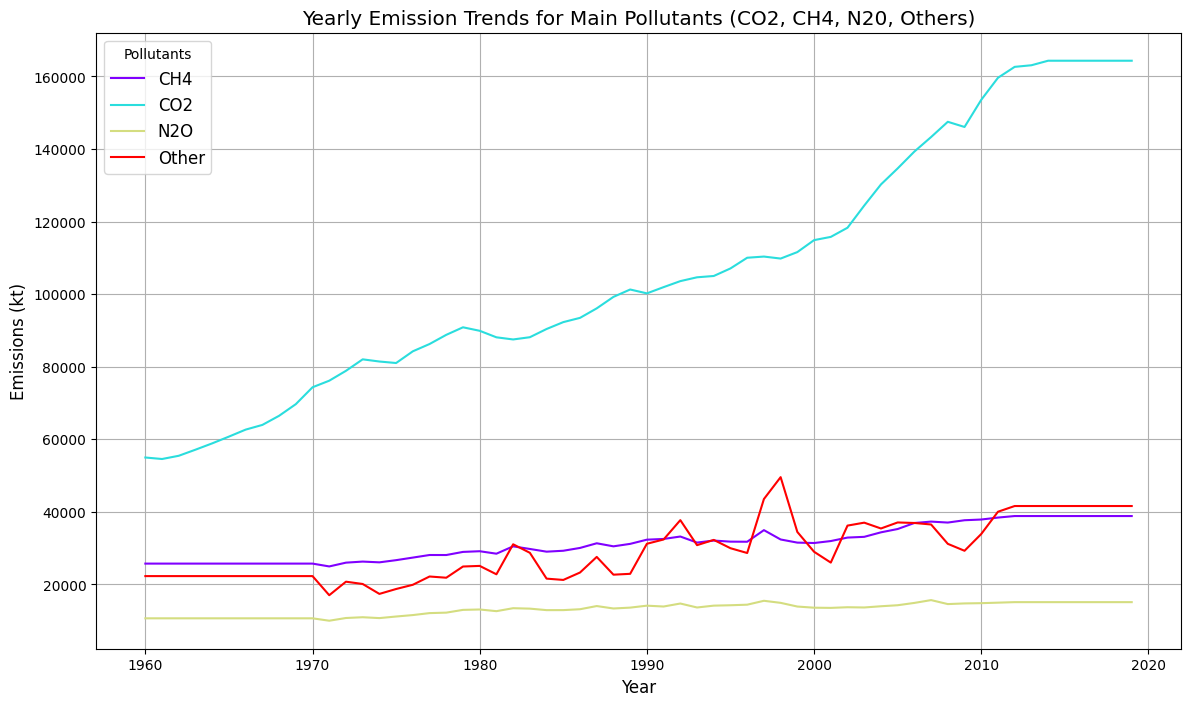

In [98]:
# plot means to identify trends
Emissions_C_df_pivot.plot(
    kind = "line",
    figsize = (14, 8),
    cmap = "rainbow"
)

plt.title("Yearly Emission Trends for Main Pollutants (CO2, CH4, N20, Others)", fontsize = "x-large")
plt.xlabel("Year", fontsize = "large")
plt.ylabel("Emissions (kt)", fontsize = "large")
plt.legend(title = "Pollutants", fontsize = "large")
plt.grid()
plt.show()

Based on the plot outlining yearly emissions trends for  main pollutants, CO2 has had the highest amount of emissions since 1960. It has also increased steadily and significantly over time from 79531 kt in 1960 to 250775 kt in 2019.

Both CH4 and N20 emissions seem to have been relatively stable throughout the years with slower growth compared to CO2.

Finally, emissions from other pollutants have grown throughout the years with periods of sharp increases and decreases (e.g. 1997). As opposed to CO2 emissions, it has not grown steadily.

-------

<h4>7.2</h4>
<p>What can you say about the <em>distribution</em> of emissions around the globe over the years? What information can you extract from the <em>tails</em> of these distributions over the years?</p>

**Answer.**

CO2 is the dominant pollutant with emissions steadily tripling from 1960 to 2019. This suggests limited global success in curbing emissions.

N2O and CH4 show minimal increase in emissions over the years, while other pollutants display several spikes throughout the years.

-------

<h4>7.3</h4>
<p>Compute a plot showing the behavior of each of the four main air pollutants for each of the main global regions in the <code>Emissions_R_df</code> data frame. The main regions are <code>'Latin America &amp; Caribbean', 'South Asia', 'Sub-Saharan Africa', 'Europe &amp; Central Asia', 'Middle East &amp; North Africa', 'East Asia &amp; Pacific'</code> and <code>'North America'</code>. What conclusions can you make?</p>

**Answer.**

In [101]:
# create a list of main regions of interest
main_regions = ["Latin America & Caribbean", "South Asia", "Sub-Saharan Africa", "Europe & Central Asia", "Middle East & North Africa", "East Asia & Pacific", "North America"]

# filter out rows with the main pollutants and regions
Emissions_R_df_main = Emissions_R_df[
    Emissions_R_df["Indicator Name"].isin(main_pollutants) &
    Emissions_R_df["Country Name"].isin(main_regions)
]

# rename the Country Name column
Emissions_R_df_main = Emissions_R_df_main.rename(columns = {"Country Name": "Region Name", "Country Code": "Region Code"})

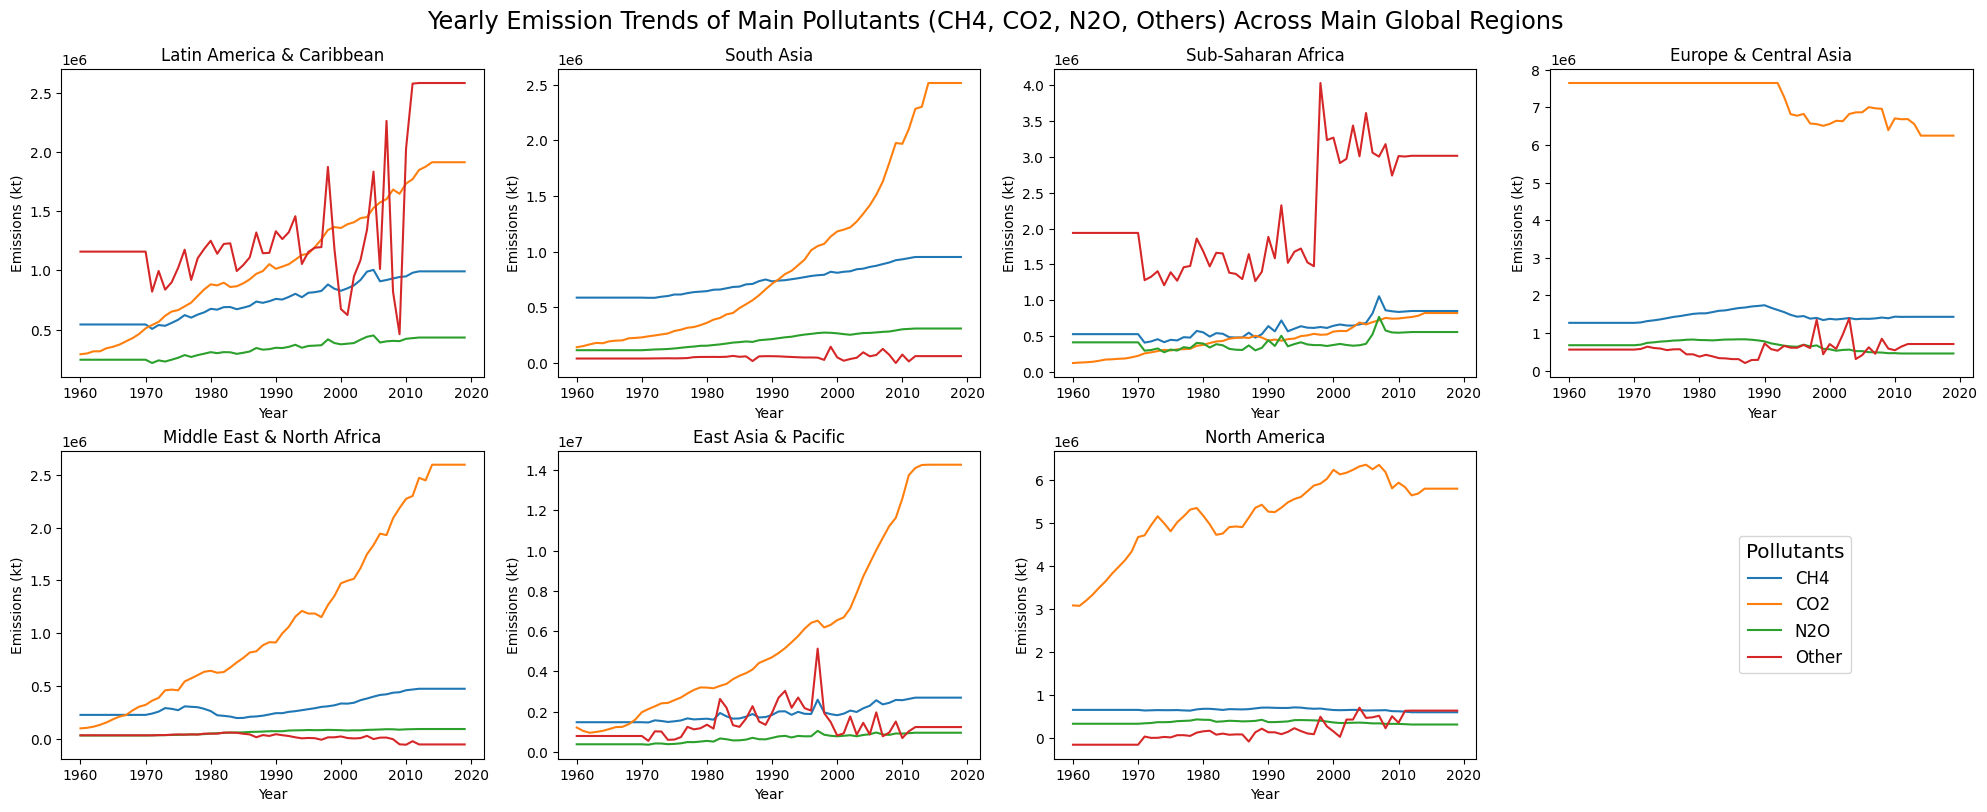

In [102]:
# setup subplots
fig, axes = plt.subplots(nrows = 2, ncols = 4, figsize = (20, 8.5), sharex = False, sharey = False)

# remove extra subplot (if odd number of regions)
axes = axes.flatten()
if len(axes) > len(main_regions):
    for i in range(len(main_regions), len(axes)):
        fig.delaxes(axes[i])

# plot for each region
for ax, region in zip(axes, main_regions):
    region_data = Emissions_R_df_main[Emissions_R_df_main["Region Name"] == region]
    region_data_pivot = region_data.pivot(index = "Year", columns = "Indicator Name", values = "Indicator Value")
    
    region_data_pivot.plot(ax = ax, legend = False)
    ax.set_title(region)
    ax.set_xlabel("Year")
    ax.set_ylabel("Emissions (kt)")

# add a global legend
fig.legend(
    region_data_pivot.columns,
    loc = "center",
    bbox_to_anchor = (0.9, 0.25),
    title = "Pollutants",
    title_fontsize = "x-large",
    fontsize = "large"
    )

fig.tight_layout()
plt.suptitle(
    "Yearly Emission Trends of Main Pollutants (CH4, CO2, N2O, Others) Across Main Global Regions",
    fontsize = "xx-large",
    y = 0.95
)
plt.subplots_adjust(top=0.88)

plt.show()


-------

<p>It seems that countries in East Asia and the Pacific are the worst dealing with pollutant emissions. We also see that Europe and Central Asia have been making some efforts to reduce their emissions. Surprisingly this is not the case with North America, Middle East and North Africa and Latin America and Carribbean, whose levels have been increasing over the years as well. </p>

<h3>Exercise 8:</h3>
<p>In Exercise 7 we discovered some interesting features of the distribution of the emissions over the years. Let us explore these features in more detail. </p>

<h4>8.1</h4>
<p>Which are the top five countries that have been in the top 10 of <code>CO2</code> emitters over the years? Have any of these countries made efforts to reduce the amount of CO2 emissions over the last 10 years?</p>

**Answer.**

In [103]:
Emissions_C_df

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Indicator Value
420,Afghanistan,AFG,CO2,EN.ATM.CO2E.KT,1960,414.371000
421,Afghanistan,AFG,CO2,EN.ATM.CO2E.KT,1961,491.378000
422,Afghanistan,AFG,CO2,EN.ATM.CO2E.KT,1962,689.396000
423,Afghanistan,AFG,CO2,EN.ATM.CO2E.KT,1963,707.731000
424,Afghanistan,AFG,CO2,EN.ATM.CO2E.KT,1964,839.743000
...,...,...,...,...,...,...
665275,Zimbabwe,ZWE,Total,EN.ATM.GHGT.KT.CE,2015,72057.803322
665276,Zimbabwe,ZWE,Total,EN.ATM.GHGT.KT.CE,2016,72057.803322
665277,Zimbabwe,ZWE,Total,EN.ATM.GHGT.KT.CE,2017,72057.803322
665278,Zimbabwe,ZWE,Total,EN.ATM.GHGT.KT.CE,2018,72057.803322


In [104]:
# filter for CO2 emissions
Emissions_C_df_top = (
    Emissions_C_df[Emissions_C_df["Indicator Name"] == "CO2"]
    .sort_values(by = ["Year", "Indicator Value"], ascending = [True, False])
    .groupby("Year")
    .head(10)
    .drop(columns = ["Country Code", "Indicator Name", "Indicator Code"])
)

# count how many times each country appears in the top 10 list
top_10_frequency = (
    Emissions_C_df_top.groupby("Country Name")["Year"]
    .count()
    .reset_index()
    .rename(columns = {"Year": "Frequency"})
)

# find the top 5 countries
top_5_countries = (
    top_10_frequency.sort_values(by = "Frequency", ascending = False)
    .head(5)
)

top_5_countries

,Country Name,Frequency
1,China,60
8,Japan,60
3,Germany,60
18,United States,60
13,Russian Federation,60


The top 5 countries that have been in the top 10 of CO2 emitters every year is China, Japan, Germany, United States and Russian Federation.

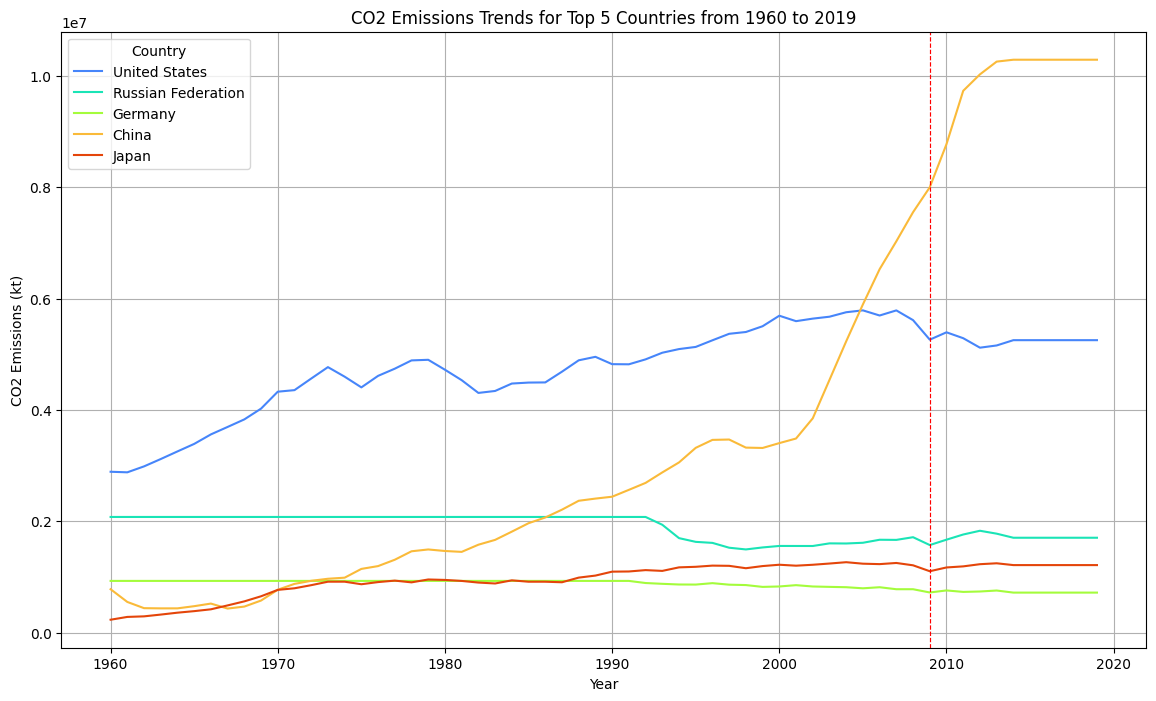

In [105]:
# create a list of top countries
top_countries_list = list(top_5_countries["Country Name"])

# filter the CO2 emissions dataset for the top 5 countries
Emissions_C_df_top_5 = (
    Emissions_C_df_top[Emissions_C_df_top["Country Name"].isin(top_countries_list)]
)

# plot the figure
plt.figure(figsize = (14, 8))

sns.lineplot(
    data = Emissions_C_df_top_5,
    x = "Year",
    y = "Indicator Value",
    hue = "Country Name",
    palette = "turbo"
)

plt.axvline(x = 2009, color = "red", linestyle = "--", linewidth = 0.85)

plt.title("CO2 Emissions Trends for Top 5 Countries from 1960 to 2019")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions (kt)")
plt.legend(title = "Country", loc = "upper left")
plt.grid(True)
plt.show()


The only country that seems to have made reductions in CO2 emissions in the past 10 years is the United States, however, this is likely due to missing data from other countries that were interpolated using forward fill. Therefore, we cannot conclude with certainty that other countries have not made similare reductions in CO2 emissions in recent years.

-------

<h4>8.2</h4>
<p>Are these five countries carrying out the burden of most of the emissions emitted over the years globally? Can we say that the rest of the world is making some effort to control their polluted gasses emissions over the years?</p>

**Answer.**

In [106]:
# create dataframe of total global emissions by year
total_global_emissions = (
    Emissions_C_df[Emissions_C_df["Indicator Name"] == "CO2"]
    .groupby("Year")["Indicator Value"]
    .sum()
    .reset_index()
    .rename(columns = {"Indicator Value": "Total Global Emissions"})
)

top_5_total_emissions = (
    Emissions_C_df_top_5
    .groupby("Year")["Indicator Value"]
    .sum()
    .reset_index()
    .rename(columns = {"Indicator Value": "Total Emissions from Top 5 Countries"})
)

emissions_contributions = total_global_emissions.merge(top_5_total_emissions, on = "Year")

emissions_contributions["% Contribution from Top 5 Countries"] = (
    emissions_contributions["Total Emissions from Top 5 Countries"] /
    emissions_contributions["Total Global Emissions"] * 100
).round(2)

emissions_contributions

,Year,Total Global Emissions,Total Emissions from Top 5 Countries,% Contribution from Top 5 Countries
0,1960,1.132488e+07,6.912845e+06,61.04
1,1961,1.123988e+07,6.724332e+06,59.83
2,1962,1.142363e+07,6.729429e+06,58.91
3,1963,1.176921e+07,6.889791e+06,58.54
4,1964,1.212782e+07,7.060878e+06,58.22
5,1965,1.251165e+07,7.262457e+06,58.05
6,1966,1.290821e+07,7.513052e+06,58.20
7,1967,1.317496e+07,7.627466e+06,57.89
8,1968,1.369297e+07,7.871491e+06,57.49
9,1969,1.435358e+07,8.264586e+06,57.58


The top 5 countries consistently contributes over 50% of global CO2 emissions, meaning they carry the burden of msot of the emissions emitted over the years globally.

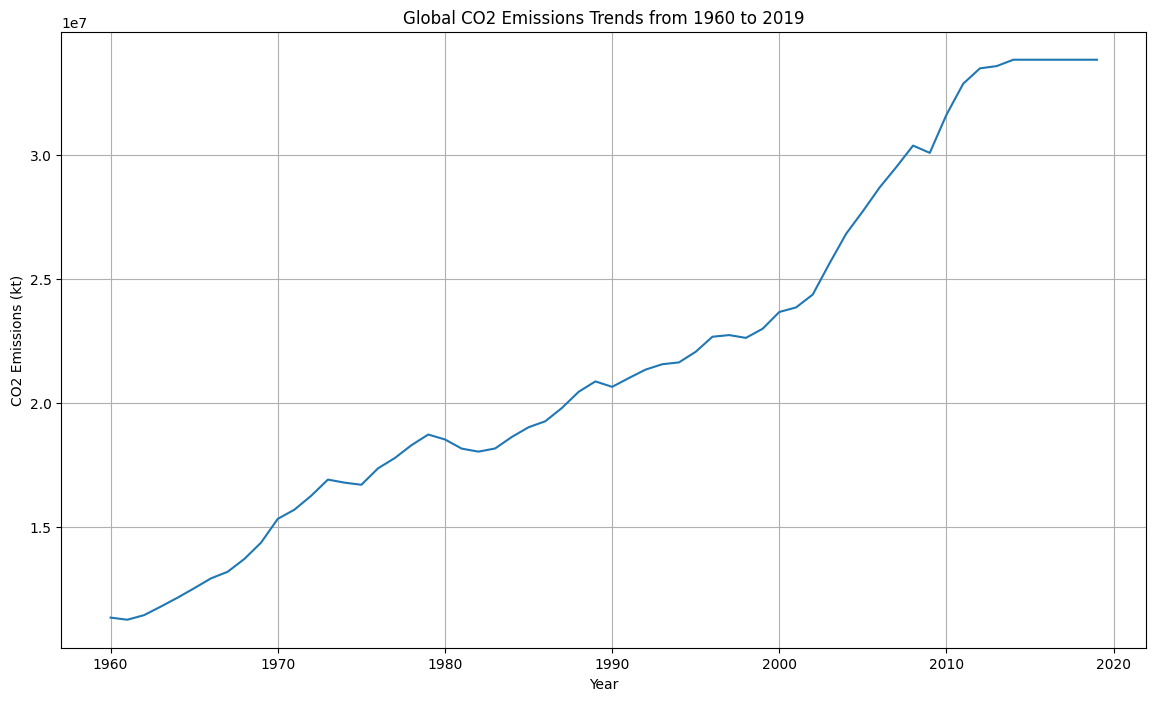

In [107]:
plt.figure(figsize = (14, 8))

sns.lineplot(
    data = total_global_emissions,
    x = "Year",
    y = "Total Global Emissions",
)

plt.title("Global CO2 Emissions Trends from 1960 to 2019")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions (kt)")
plt.grid(True)
plt.show()


The rest of the world does not seem to be making much effort to reduce their CO2 emissions in recent years, though it has seemed to plateau since 2011.

-------

<h2>The health impacts of air pollution</h2>

<h3>Exercise 9:</h3>
<p>One of the main contributions of poor health from air pollution is particulate matter. In particular, very small particles (those with a size less than 2.5 micrometres ($\mu$m)) can enter and affect the respiratory system. The <code>PM2.5</code> indicator measures the average level of exposure of a nation's population to concentrations of these small particles. The <code>PM2.5_WHO</code> measures the  percentage of the population who are exposed to ambient concentrations of these particles that exceed some thresholds set by the World Health Organization (WHO). In particular, countries with a higher <code>PM2.5_WHO</code> indicator are more likely to suffer from bad health conditions. </p>
<h4>9.1</h4>
<p>The client would like to know if there is any relationship between the <code>PM2.5_WHO</code> indicator and the level of income of the general population, as well as how this changes over time. What plot(s) might be helpful to solve the client's question?  What conclusion can you draw from your plot(s) to answer their question?</p>
<p><strong>Hint:</strong> The DataFrame <code>WDI_countries</code> contains a column named <code>Income Group</code>. </p>

**Answer.**

In [108]:
WDI_country

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Unnamed: 30
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,NaN,Latin America & Caribbean,High income,AW,...,NaN,Enhanced General Data Dissemination System (e-...,2010,NaN,NaN,Yes,NaN,NaN,2016.0,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,NaN,South Asia,Low income,AF,...,Consolidated central government,Enhanced General Data Dissemination System (e-...,1979,"Demographic and Health Survey, 2015","Integrated household survey (IHS), 2016/17",NaN,NaN,NaN,2017.0,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,NaN,Sub-Saharan Africa,Lower middle income,AO,...,Budgetary central government,Enhanced General Data Dissemination System (e-...,2014,"Demographic and Health Survey, 2015/16","Integrated household survey (IHS), 2008/09",NaN,NaN,NaN,2017.0,NaN
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,...,Consolidated central government,Enhanced General Data Dissemination System (e-...,2011,"Demographic and Health Survey, 2017/18",Living Standards Measurement Study Survey (LSM...,Yes,2012,2013.0,2017.0,NaN
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income,AD,...,NaN,NaN,2011. Population data compiled from administra...,NaN,NaN,Yes,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,XKX,Kosovo,Kosovo,Republic of Kosovo,XK,Euro,NaN,Europe & Central Asia,Upper middle income,XK,...,NaN,Enhanced General Data Dissemination System (e-...,2011,"Multiple Indicator Cluster Survey, 2013/14","Expenditure survey/budget survey (ES/BS), 2015",NaN,2014,NaN,NaN,NaN
259,YEM,Yemen,"Yemen, Rep.",Republic of Yemen,YE,Yemeni rial,NaN,Middle East & North Africa,Low income,RY,...,NaN,Enhanced General Data Dissemination System (e-...,2004,"Demographic and Health Survey, 2013","Expenditure survey/budget survey (ES/BS), 2014",NaN,NaN,2012.0,2017.0,NaN
260,ZAF,South Africa,South Africa,Republic of South Africa,ZA,South African rand,Fiscal year end: March 31; reporting period fo...,Sub-Saharan Africa,Upper middle income,ZA,...,Consolidated central government,Special Data Dissemination Standard (SDDS),2011,"Demographic and Health Survey, 2016","Expenditure survey/budget survey (ES/BS), 2014/15",NaN,2007,2010.0,2017.0,NaN
261,ZMB,Zambia,Zambia,Republic of Zambia,ZM,New Zambian kwacha,National accounts data were rebased to reflect...,Sub-Saharan Africa,Lower middle income,ZM,...,Budgetary central government,Enhanced General Data Dissemination System (e-...,2010,"Demographic and Health Survey, 2013/14","Integrated household survey (IHS), 2015",NaN,NaN,1994.0,2017.0,NaN


In [153]:
# create dataframe of income groups
income_group_df = WDI_country[["Table Name", "Income Group"]]

# filter out regions
income_group_df = income_group_df[~income_group_df["Table Name"].isin(regions)].rename(columns = {"Table Name": "Country Name"})

# standardize country name columns in both dataframes
Emissions_C_df["Country Name"] = (
    Emissions_C_df["Country Name"]
    .str.strip()
    .str.lower()
    .str.replace("’", "'", regex=False)
)

income_group_df["Country Name"] = (
    income_group_df["Country Name"]
    .str.strip()
    .str.lower()
    .str.replace("’", "'", regex=False)
)

# rename countries discrepant with Emissions_C_df
manual_mapping = {
    "not classified": None,
    "korea, dem. people’s rep.": "korea, dem. people's rep.",
    "côte d'ivoire": "cote d'ivoire",
    "curaçao": "curacao",
    "são tomé and principe": "sao tome and principe"
}

income_group_df["Country Name"] = income_group_df["Country Name"].replace(manual_mapping)

# merge income group data with emissions data
Emissions_C_df_with_income = Emissions_C_df.merge(
    income_group_df,
    on = "Country Name",
    how = "left"
)

# filter out "Not Classified" and filter for PM2.5_WHO
Emissions_C_df_with_income = Emissions_C_df_with_income[
    (Emissions_C_df_with_income["Country Name"] != "not classified") &
    (Emissions_C_df_with_income["Indicator Name"] == "PM2.5_WHO")
]

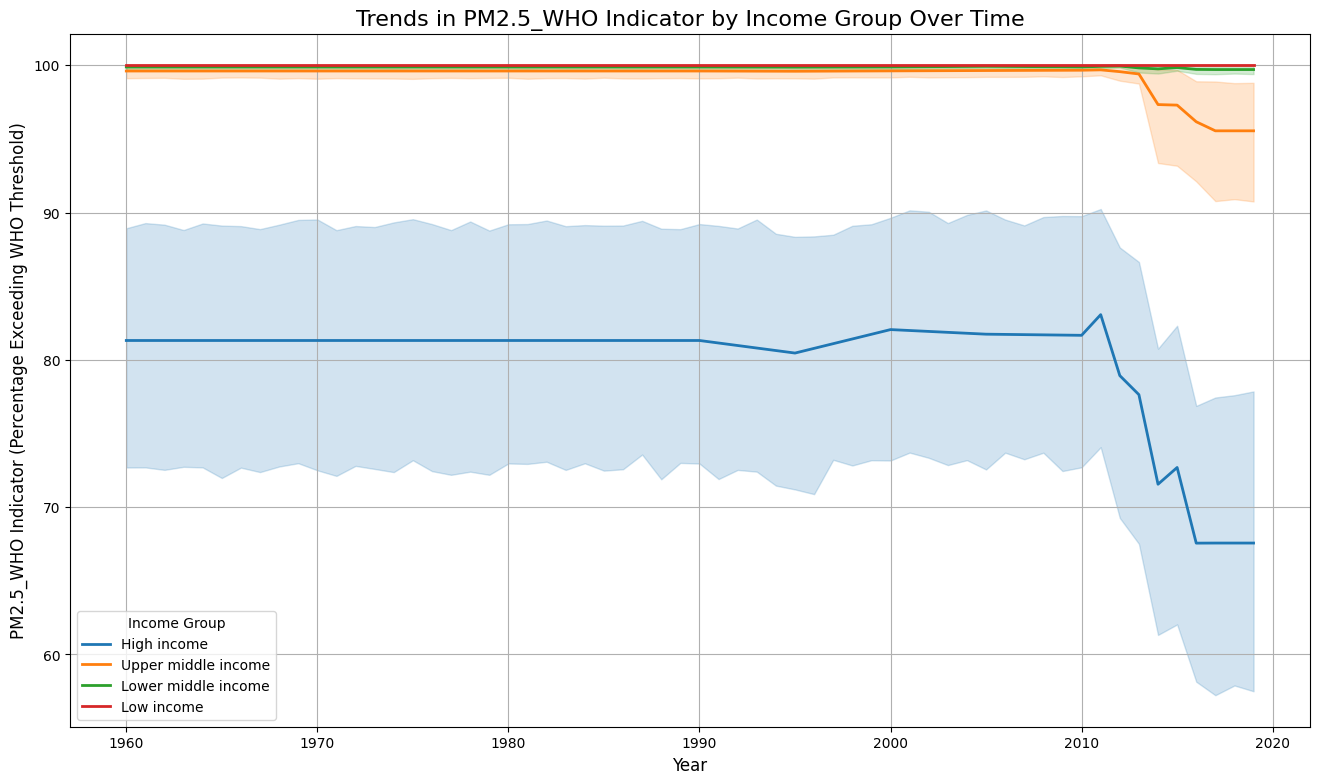

In [159]:
# create income group list
income_groups = ["High income", "Upper middle income", "Lower middle income", "Low income"]

# plot for each income group
plt.figure(figsize=(16, 9))

for income_group in income_groups:
    group_data = Emissions_C_df_with_income[Emissions_C_df_with_income["Income Group"] == income_group]
    sns.lineplot(
        data = group_data,
        x = "Year",
        y = "Indicator Value",
        label = income_group,
        linewidth = 2
    )

plt.title("Trends in PM2.5_WHO Indicator by Income Group Over Time", fontsize = 16)
plt.xlabel("Year", fontsize = 12)
plt.ylabel("PM2.5_WHO Indicator (Percentage Exceeding WHO Threshold)", fontsize = 12)
plt.legend(title = "Income Group", loc = "lower left")
plt.grid(True)
plt.show()


**Best plot:** A lineplot would be the optimal choice to model PM2.5_WHO indicator values, the level income of the general population as well as time.

**Conclusions based on income group**: Based on the plot, the higher a country's income group, the lower the PM2.5_WHO levels. High-income countries have consistently lower percentage of their populations exposed to PM2.5 levels exceeding WHO thresholds compared to other income groups while upper-middle, lower-middle and low-income countries have high exposure levels close to 100%. This trend likely corresponds to better health outcomes in high-income countries compared to other countries.

**Conclusions based on time**: Post-2010, there's a significant downward trend in exposure percentages among high-income countries. This could reflect better pollution control measures and improvements in air quality policies. There is some progress in reducing exposure in upper-middle-income countries post-2010 as well. However, the reduction is not as significant as that of high-income countries. No decrease in exposure levels can be seen for lower-middle or low income countries throughout the years.

-------

<h4>9.2</h4>
<p>What do you think are the causes behind the results in Exercise 9.1?</p>

**Answer.**

**Income Group**
</p>The lower exposure levels in high income countries could reflect greater funds allocated to better pollution control measures as well as better ability to focus on improving air quality policies. Low income and lower-middle income countries, on the other hand, may not have sufficient funds or technologies to be directed to environmental policies. They may also have other competing priorities such as economic growth (which may at times rely on polluting energy sources), access to potable water, healthcare and education.</p>

**Time**
</p>Improvements in pollutant exposure levels in recent years could reflect advancements in our understanding of pollution, greater awareness prompting individuals to opt for renewable energy sources, and better technology to improve air quality

-------

<h3>Exercise 10:</h3>
<p>Finally, our client is interested in investigating the impacts and relationships between <strong>high levels of exposure to particle matter</strong> and <strong>the health of the population</strong>. Coming up with additional data for this task may be infeasible for the client, thus they have asked us to search for relevant health data in the <code>WDIdata.csv</code> file and work with that. </p>

<h4>10.1</h4>
<p>Which indicators present in the file  <code>WDISeries.csv</code> file might be useful to solve the client's question? Explain.</p>
<p><strong>Note:</strong> Naming one or two indicators is more than enough for this question. </p>

**Answer.**

In [160]:
health_indicators = [name for name in WDI_data["Indicator Name"].unique() if "pollution" in name]
list(health_indicators)

['Mortality rate attributed to household and ambient air pollution, age-standardized (per 100,000 population)',
 'Mortality rate attributed to household and ambient air pollution, age-standardized, female (per 100,000 female population)',
 'Mortality rate attributed to household and ambient air pollution, age-standardized, male (per 100,000 male population)',
 'PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)',
 'PM2.5 air pollution, population exposed to levels exceeding WHO guideline value (% of total)',
 'PM2.5 pollution, population exposed to levels exceeding WHO Interim Target-1 value (% of total)',
 'PM2.5 pollution, population exposed to levels exceeding WHO Interim Target-2 value (% of total)',
 'PM2.5 pollution, population exposed to levels exceeding WHO Interim Target-3 value (% of total)']

In [161]:
exposure_indicators = [name for name in WDI_data["Indicator Name"].unique() if "exposure" in name]
list(exposure_indicators)

['PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)']

Two indicators that could be used to solve the client's question are "Mortality rate attributed to household and ambient air pollution, age-standardized (per 100,000 population)" and "P2.5 air pollution, mean annual exposure (micrograms per cubic meter)"

-------

<h4>10.2</h4>
<p>Use the indicators provided in Exercise 10.1 to give valuable information to the client. </p>

**Answer.**

In [179]:
# filter out data for air pollution
pollution_df = WDI_data[
    (WDI_data["Indicator Name"] == "Mortality rate attributed to household and ambient air pollution, age-standardized (per 100,000 population)") |
    (WDI_data["Indicator Name"] == "PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)")
]

# drop irrelevant columns
pollution_df = pollution_df.drop(columns = ["Country Code", "Indicator Code", "Unnamed: 64"])

# melt the dataframe
pollution_df = pd.melt(
    pollution_df,
    id_vars = ["Country Name", "Indicator Name"],
    var_name = "Year",
    value_name = "Indicator Value"
)

# pivot the dataframe
pollution_df = pollution_df.pivot(
    index = ["Country Name", "Year"],
    columns = "Indicator Name",
    values = "Indicator Value"
).reset_index()

# rename columns
pollution_df = pollution_df.rename(columns = {
    "Mortality rate attributed to household and ambient air pollution, age-standardized (per 100,000 population)": "Mortality Rate",
    "PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)": "PM2.5 Exposure"
})

# filter out missing values
pollution_df = pollution_df.dropna(subset = ["Mortality Rate", "PM2.5 Exposure"])

# filter out regions
pollution_df = pollution_df[~pollution_df["Country Name"].isin(regions)]

pollution_df

Indicator Name,Country Name,Year,Mortality Rate,PM2.5 Exposure
56,Afghanistan,2016,211.1,56.287047
116,Albania,2016,68.0,18.189934
176,Algeria,2016,49.7,39.853274
356,Angola,2016,118.5,31.785389
416,Antigua and Barbuda,2016,29.9,18.460930
...,...,...,...,...
15416,"Venezuela, RB",2016,34.6,16.767994
15476,Vietnam,2016,64.5,30.241312
15716,"Yemen, Rep.",2016,194.2,50.127626
15776,Zambia,2016,127.2,27.355674


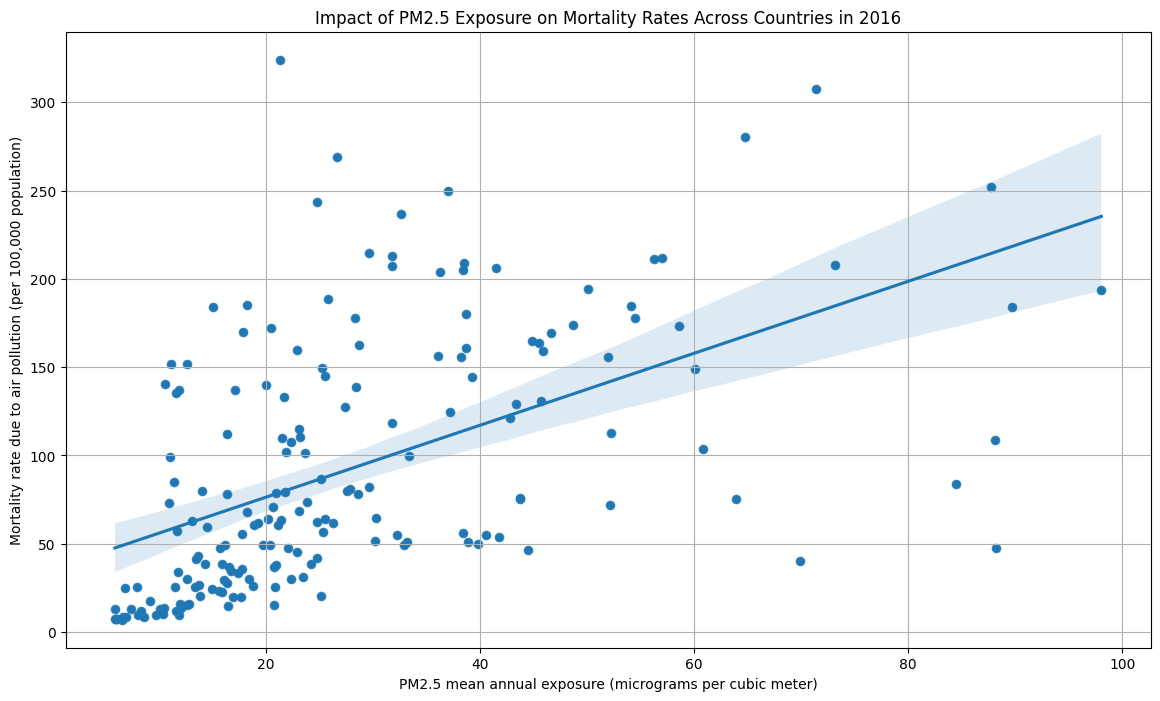

In [180]:
# plot graph
plt.figure(figsize = (14, 8))

sns.scatterplot(
    data = pollution_df,
    x = "PM2.5 Exposure",
    y = "Mortality Rate"
)

sns.regplot(data = pollution_df, x = "PM2.5 Exposure", y = "Mortality Rate")

plt.title("Impact of PM2.5 Exposure on Mortality Rates Across Countries in 2016")
plt.xlabel("PM2.5 mean annual exposure (micrograms per cubic meter)")
plt.ylabel("Mortality rate due to air pollution (per 100,000 population)")
plt.grid(True)
plt.show()

Based on the data available in WDI_data, positive linear correlation can be found between PM2.5 mean annual exposure and mortality rate due to air pollution (i.e. higher mean annual exposure resulted in higher mortality rates due to air pollution in 2016).

-------

<h4>10.3</h4>
<p>Extend the analysis above to find some countries of interest. These are defined as</p>
<ul>
<li>The countries that have a high mortality rate due to household and ambient air pollution, but with low PM2.5 exposure</li>
<li>The countries that have a low mortality rate due to household and ambient air pollution, but with high PM2.5 exposure</li>
</ul>

**Answer.**

In [181]:
# average PM2.5 exposure
avg_pm25 = pollution_df["PM2.5 Exposure"].mean()

# filter out countries with high and low PM2.5 exposures
high_pollution_df = pollution_df[pollution_df["PM2.5 Exposure"] > avg_pm25]
low_pollution_df = pollution_df[pollution_df["PM2.5 Exposure"] <= avg_pm25]

# average mortality rate for each subset
avg_mortality_high_pollution = high_pollution_df["Mortality Rate"].mean()
avg_mortality_low_pollution = low_pollution_df["Mortality Rate"].mean()

# subset for high mortality-low exposure and low mortality-high exposure
low_mortality_high_exposure = high_pollution_df[high_pollution_df["Mortality Rate"] <= avg_mortality_high_pollution]
high_mortality_low_exposure = low_pollution_df[low_pollution_df["Mortality Rate"] <= avg_mortality_low_pollution]

# list countries
lmhe_list = list(low_mortality_high_exposure["Country Name"].unique())
hmle_list = list(high_mortality_low_exposure["Country Name"].unique())

# print results
print(f"Countries with low mortality and high exposures:")
print(lmhe_list)
print("-------------------------------------------------------------")
print(f"Countries with high mortality and low exposures:")
print(hmle_list)


Countries with low mortality and high exposures:
['Algeria', 'Angola', 'Armenia', 'Bahrain', 'Bhutan', 'Cabo Verde', 'China', 'Congo, Rep.', 'Egypt, Arab Rep.', 'Gabon', 'Iran, Islamic Rep.', 'Iraq', 'Jordan', 'Kenya', 'Kuwait', 'Lebanon', 'Libya', 'Morocco', 'North Macedonia', 'Oman', 'Qatar', 'Rwanda', 'Saudi Arabia', 'Syrian Arab Republic', 'Tajikistan', 'Tanzania', 'Tunisia', 'Turkey', 'United Arab Emirates', 'Uzbekistan', 'Vietnam']
-------------------------------------------------------------
Countries with high mortality and low exposures:
['Antigua and Barbuda', 'Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Barbados', 'Belarus', 'Belgium', 'Bolivia', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Grenada', 'Honduras', 'Hungary', 'Iceland', 'Ireland', 'Israel'

-------

<h4>10.4</h4>
<p>Finally, we want to look at the mortality data by income. We expect higher income countries to have lower pollution-related mortality. Find out if this assumption holds. Calculate summary statistics and histograms for each income category and note any trends.</p>

**Answer.**

In [182]:
pollution_df

Indicator Name,Country Name,Year,Mortality Rate,PM2.5 Exposure
56,Afghanistan,2016,211.1,56.287047
116,Albania,2016,68.0,18.189934
176,Algeria,2016,49.7,39.853274
356,Angola,2016,118.5,31.785389
416,Antigua and Barbuda,2016,29.9,18.460930
...,...,...,...,...
15416,"Venezuela, RB",2016,34.6,16.767994
15476,Vietnam,2016,64.5,30.241312
15716,"Yemen, Rep.",2016,194.2,50.127626
15776,Zambia,2016,127.2,27.355674


In [ ]:
pollution_df["Country Name"] = pollution_df["Country Name"].str.lower()

# Create a dictionary for mapping
income_mapping = dict(zip(income_group_df["Country Name"], income_group_df["Income Group"]))

# add the income group column to pollution_df
pollution_df["Income Group"] = pollution_df["Country Name"].map(income_mapping)

# group by income group and calculate summary statistics
summary_stats = pollution_df.groupby("Income Group")["Mortality Rate"].describe().reset_index()

summary_stats



,Income Group,count,mean,std,min,25%,50%,75%,max
0,High income,52.0,25.142308,19.123534,7.0,11.900,20.00,33.625,103.8
1,Low income,30.0,187.713333,53.746940,75.2,156.675,189.05,212.575,324.1
2,Lower middle income,46.0,136.441304,55.566699,41.9,101.850,138.40,167.725,307.4
3,Upper middle income,54.0,63.937037,29.618125,23.3,46.800,61.10,77.950,177.7


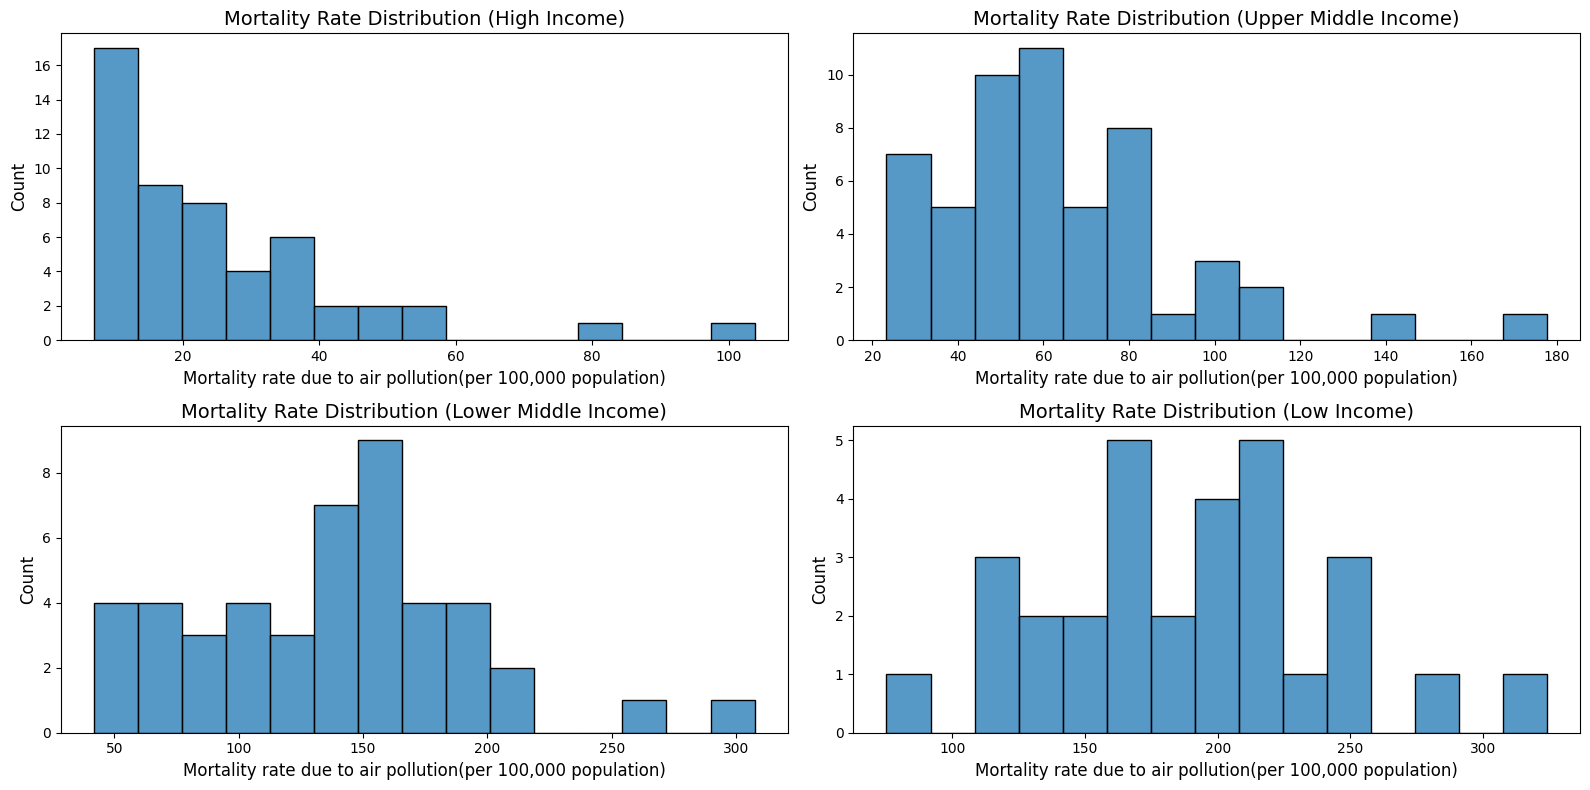

In [215]:
# set up figure
plt.figure(figsize = (16, 8))

# plot histogram
for i, income_group in enumerate(income_groups, start = 1):
    plt.subplot(2, 2, i)

    group_data = pollution_df[pollution_df["Income Group"] == income_group]

    sns.histplot(
        data = group_data,
        x = "Mortality Rate",
        bins = 15,
        stat = "count"
    )

    plt.title(f"Mortality Rate Distribution ({income_group.title()})", fontsize=14)
    plt.xlabel("Mortality rate due to air pollution(per 100,000 population)", fontsize=12)
    plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

**High-income countries** have significantly lower mortality rates due to air pollution compared to other income groups with an average of 25. Most high-income countries also tend to have mortality rates concentrated below 33.

Mortality rates due to air pollution are more varied in **upper-middle-income countries** compared to high-income countries, with the majority of rates clustered between 40 and 100.

**Lower-middle-income** countries have significantly higher max mortality rates than both high-income and upper-middle-income countries, with a max of 307. The distribution of rates is larger and more uniform than that of high-income and upper-middle-income countries, and spans between 41 and 307.

**Lower-income** countries have the highest mortality rates among all income groups, with the largest average rate of 75. Many low-income countries experience rates over 150.

Based on the data, there is an inverse relationship of air-pollution-related mortality rates with income, whereby higher-income groups tend to have lower mortality rates, while lower-income groups have significantly higher rates. Similarly, higher-income countries tend to have a lower range of air-pollution-related deaths while lower-income countries tend to have larger ranges.

-------

<h4>10.5</h4>
<p>At the start, we asked some questions. Based on your analysis, provide a short answer to each of these:</p>
<ol>
<li>Are we making any progress in reducing the amount of emitted pollutants across the globe?</li>
<li>Which are the critical regions where we should start environmental campaigns?</li>
<li>Are we making any progress in the prevention of deaths related to air pollution?</li>
<li>Which demographic characteristics seem to correlate with the number of health-related issues derived from air pollution? </li>
</ol>

**Answer.**

1. We are making limited progress, if any, in reducing the amount of emitted pollutants across the globe, as evidenced by the significant increase in CO2 emissions over the decades.
2. East Asia & the Pacific are critical regions where environmental campaigns should begin, given their significantly higher CO2 emissions. Additionally, North America, the Middle East & North Africa, and Europe & Central Asia also require focus due to their persistently high CO2 emission rates.
3. Progress in preventing deaths related to air pollution is limited and largely confined to high- and upper-middle-income countries, where funding and frameworks for environmental campaigns are more robust. Lower-income countries continue to face severe health impacts due to air pollution.
4. Income level seems to correlate with the number of health-related issues derived from air pollution, with lower-income groups experiencing disproportionately higher rates of death

-------